In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
ring = pd.read_csv("wang_ring2.csv")
watch = pd.read_csv("watch_example.csv")
watch.drop("sub_index", axis=1, inplace=True)

In [3]:
ring.dtypes

timestamp      str
rri_ms       int64
asc_area     int64
desc_area    int64
motion       int64
dtype: object

In [4]:
watch.dtypes

record_time      str
rri            int64
area_up        int64
area_down      int64
motion         int64
dtype: object

In [5]:
watch.head(5)

,record_time,rri,area_up,area_down,motion
0,2025-03-12 09:04:25,750,7,212,938
1,2025-03-12 09:04:25,610,5,210,375
2,2025-03-12 09:04:26,760,3,208,57
3,2025-03-12 09:04:27,870,1,206,40
4,2025-03-12 09:04:28,900,0,204,7


In [12]:
watch.dtypes

record_time      str
rri            int64
area_up        int64
area_down      int64
motion         int64
dtype: object

In [6]:
ring.head(5)

,timestamp,rri_ms,asc_area,desc_area,motion
0,2026-05-26 11:15:43,1159,126,428,142
1,2026-05-26 11:15:44,1114,125,413,0
2,2026-05-26 11:15:45,1069,125,398,0
3,2026-05-26 11:15:46,1024,124,383,0
4,2026-05-26 11:15:47,980,124,368,0


<Axes: >

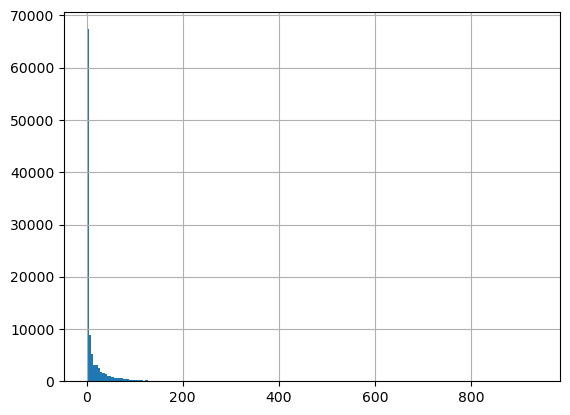

In [7]:
watch.motion.hist(bins=200)

<Axes: >

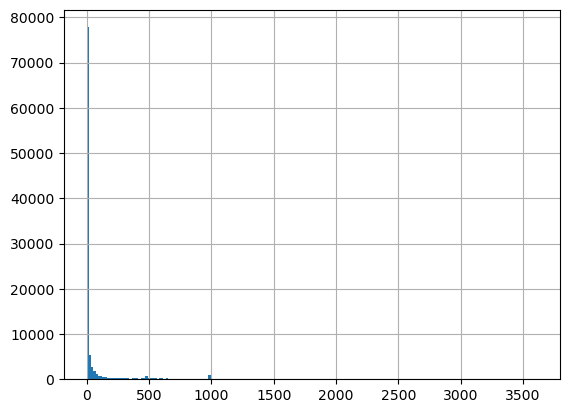

In [8]:
ring.motion.hist(bins=200)

<Axes: >

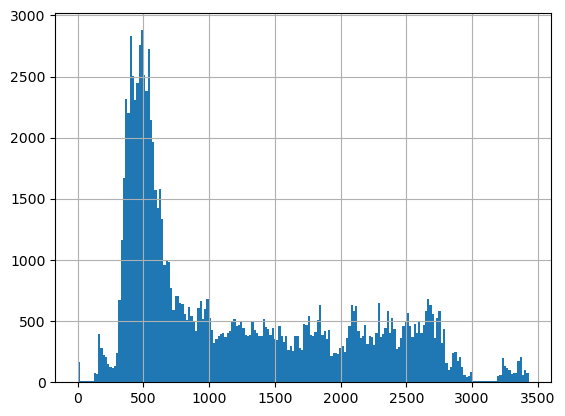

In [9]:
watch.area_up.hist(bins=200)

<Axes: >

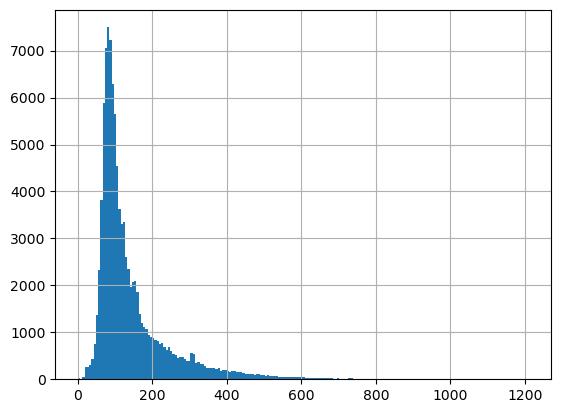

In [11]:
ring.asc_area.hist(bins=200)

In [13]:
import pandas as pd
import numpy as np

def judge_area_calculation_method(df):
    """
    通过统计分析和生理学约束，判断 PPG area_up 和 area_down 的计算方式。
    期望的 DataFrame 包含: 'rri', 'area_up', 'area_down'
    """
    print("🔍 启动 PPG 面积特征诊断分析...\n")
    
    # 1. 过滤异常值 (比如 rri 为 0 或缺失的数据)
    df_clean = df[(df['rri'] > 0) & (df['rri'] < 3000)].copy()
    if len(df_clean) == 0:
        print("❌ 没有找到有效的 RRI 数据，无法分析。")
        return
        
    # 2. 基础统计概览
    print("📊 1. 基础数据量级分布:")
    desc = df_clean[['area_up', 'area_down', 'rri']].describe(percentiles=[0.5, 0.95])
    print(desc.loc[['mean', '50%', '95%', 'max']].to_string())
    print("-" * 50)
    
    # 3. 核心计算：面积之和与 RRI 的比值
    # 如果面积单位是毫秒，(area_up + area_down) 的总耗时通常不会超过整个心跳周期(RRI)太多
    df_clean['area_sum'] = df_clean['area_up'] + df_clean['area_down']
    df_clean['area_to_rri_ratio'] = df_clean['area_sum'] / df_clean['rri']
    
    max_area_val = max(df_clean['area_up'].max(), df_clean['area_down'].max())
    median_ratio = df_clean['area_to_rri_ratio'].median()
    
    print("🧬 2. 生理学约束分析:")
    print(f"   -> (area_up + area_down) / RRI 的中位数比值: {median_ratio:.2f}")
    
    # 诊断极度异常的比例 (例如总面积超过 RRI 两倍的占比)
    invalid_ratio_pct = (df_clean['area_to_rri_ratio'] > 2.0).mean() * 100
    print(f"   -> 总面积显著大于心跳周期(>2倍RRI)的异常点占比: {invalid_ratio_pct:.1f}%")
    print("-" * 50)
    
    # 4. 做出最终裁判
    print("💡 3. 诊断结论:")
    
    is_small_magnitude = max_area_val <= 5000
    is_time_constrained = median_ratio <= 1.5  # 给予1.5的容错，因为有时候舒张末期会拖得很长
    
    if is_small_magnitude and is_time_constrained:
        print("   ✅ 结论：高度确信为【归一化时间（等效脉宽，单位 ms）】！")
        print("   理由：数据量级在毫秒范围内，且 (上升面积+下降面积) 整体受限于心跳周期，符合生理学时间特征。")
        print("   状态：该数据已经过标准化处理，可直接用于下游机器学习或心血管健康分析。")
        
    elif not is_small_magnitude:
        print("   ⚠️ 结论：高度确信为【原始波形几何面积（未归一化积分）】！")
        print(f"   理由：最大值达到了 {max_area_val}，这属于 ADC 采样点的直接积分量级。")
        print("   建议：由于未做振幅消除，该特征极易受佩戴松紧影响，建议在使用前自行除以波峰振幅进行归一化。")
        
    else:
        print("   🤔 结论：【模棱两可，可能是特定算法的专有缩放】")
        print("   理由：量级虽然较小，但与 RRI 的时间约束关系被打破（面积加起来远大于周期）。")
        print("   可能是设备厂商做了一种特殊的非线性映射，或者单位并非纯粹的毫秒。")


# ==========================================
# 🚀 测试运行区 
# (你可以直接替换成你的真实 df)
# ==========================================
if __name__ == '__main__':
    # 构造一个模拟的“归一化时间”数据集来测试代码
    
    # 调用函数 (换成你的真实 DataFrame: judge_area_calculation_method(your_df))
    judge_area_calculation_method(watch)

🔍 启动 PPG 面积特征诊断分析...

📊 1. 基础数据量级分布:
         area_up   area_down          rri
mean  1204.08391  1954.79725   803.491505
50%    850.00000  1301.00000   810.000000
95%   2722.00000  4486.00000   970.000000
max   3430.00000  6227.00000  1220.000000
--------------------------------------------------
🧬 2. 生理学约束分析:
   -> (area_up + area_down) / RRI 的中位数比值: 2.88
   -> 总面积显著大于心跳周期(>2倍RRI)的异常点占比: 63.9%
--------------------------------------------------
💡 3. 诊断结论:
   ⚠️ 结论：高度确信为【原始波形几何面积（未归一化积分）】！
   理由：最大值达到了 6227，这属于 ADC 采样点的直接积分量级。
   建议：由于未做振幅消除，该特征极易受佩戴松紧影响，建议在使用前自行除以波峰振幅进行归一化。


In [14]:
import os
import glob
import pandas as pd
import numpy as np

def batch_analyze_ppg_directory(directory_path):
    """
    批量扫描指定目录下的所有 PPG 特征 CSV 文件，并输出统计汇总表。
    """
    # 获取目录下所有的 csv 文件
    file_pattern = os.path.join(directory_path, '*.csv')
    csv_files = glob.glob(file_pattern)
    
    if not csv_files:
        print(f"❌ 在目录 '{directory_path}' 下没有找到任何 CSV 文件，请检查路径。")
        return None

    print(f"📂 共找到 {len(csv_files)} 份 CSV 数据，正在逐一扫描提取特征...\n")
    
    summary_list = []
    
    for file_path in csv_files:
        file_name = os.path.basename(file_path)
        
        try:
            # 读取数据
            df = pd.read_csv(file_path)
            
            # 检查必备的列名是否存在
            required_cols = {'rri', 'area_up', 'area_down'}
            if not required_cols.issubset(df.columns):
                print(f"⚠️ 跳过 {file_name}: 缺少必要的特征列 (需包含 rri, area_up, area_down)")
                continue
                
            # 过滤掉 RRI 异常的数据（防零除）
            df_clean = df[(df['rri'] > 0) & (df['rri'] < 3000)].copy()
            
            if len(df_clean) == 0:
                print(f"⚠️ 跳过 {file_name}: 未找到有效的 RRI 数据")
                continue
                
            # --- 1. 计算基础统计量 ---
            area_up_mean = df_clean['area_up'].mean()
            area_down_mean = df_clean['area_down'].mean()
            area_up_max = df_clean['area_up'].max()
            area_down_max = df_clean['area_down'].max()
            
            # --- 2. 计算生理学诊断比值 ---
            # 计算每行的 (area_up + area_down) / rri
            df_clean['area_sum'] = df_clean['area_up'] + df_clean['area_down']
            df_clean['ratio'] = df_clean['area_sum'] / df_clean['rri']
            median_ratio = df_clean['ratio'].median()
            
            # 异常值(>2倍RRI)占比
            invalid_ratio_pct = (df_clean['ratio'] > 2.0).mean() * 100
            
            # --- 3. 自动给出诊断结论 ---
            if area_up_max > 5000 or median_ratio > 1.5:
                verdict = "🔴 原始积分(需处理)"
            else:
                verdict = "🟢 已归一化(安全)"
                
            # 将结果存入字典
            summary_list.append({
                '文件名': file_name,
                '有效行数': len(df_clean),
                'AreaUp_均值': round(area_up_mean, 1),
                'AreaUp_最大值': int(area_up_max),
                'AreaDown_最大值': int(area_down_max),
                '面积/RRI中位数': round(median_ratio, 2),
                '>2倍周期占比': f"{invalid_ratio_pct:.1f}%",
                '数据诊断结论': verdict
            })
            
        except Exception as e:
            print(f"❌ 处理文件 {file_name} 时发生错误: {e}")

    # 将所有文件的结果拼接成一个 DataFrame 并美化输出
    if summary_list:
        summary_df = pd.DataFrame(summary_list)
        
        print("=" * 95)
        print("📊 批量数据扫描结果汇总表")
        print("=" * 95)
        # 使用 to_string 对齐打印，方便终端查看
        print(summary_df.to_string(index=False))
        print("=" * 95)
        
        return summary_df
    else:
        return None

# ==========================================
# 🚀 运行区
# ==========================================
if __name__ == '__main__':
    # 将此处的路径替换为你存放这十几份数据的实际目录路径
    # 例如：target_directory = '../../../5_Data/other_device_features/'
    target_directory = r'C:\Users\snong\Desktop\20260514_YAK_Data'  
    
    result_df = batch_analyze_ppg_directory(target_directory)
    
    # 如果你想把这份体检报告保存下来备查，可以取消下面这行的注释
    # if result_df is not None:
    #     result_df.to_csv("批量面积特征体检报告.csv", index=False, encoding='utf-8-sig')

📂 共找到 25 份 CSV 数据，正在逐一扫描提取特征...

📊 批量数据扫描结果汇总表
                                     文件名   有效行数  AreaUp_均值  AreaUp_最大值  AreaDown_最大值  面积/RRI中位数 >2倍周期占比      数据诊断结论
0a9fe5d6-be24-416f-a294-aab8b2955d1b.csv 104064     1204.1        3430          6227       2.88   63.9% 🔴 原始积分(需处理)
0ab048a5-2c7c-4285-90d7-72500e6a87f5.csv  95520     1675.1        4887         10374       3.42   70.0% 🔴 原始积分(需处理)
0b0499b0-21cf-471a-b52c-44456a680dfd.csv  98208     1519.4        2815          5465       5.19   87.2% 🔴 原始积分(需处理)
0b0644f6-5d33-4ee7-899e-2b17913652b4.csv  83904      876.6        2513          5058       2.66   62.3% 🔴 原始积分(需处理)
0b0c8a66-9b55-44b5-b389-56246862e443.csv 108576      979.1        3008          5276       2.09   52.1% 🔴 原始积分(需处理)
0b0e9388-a5e8-4a0c-977a-dc3fbb591fca.csv 103392      663.2        2742          5288       1.25   36.2%  🟢 已归一化(安全)
0b4046a9-6d0f-475a-90f0-36634d324731.csv  87648     2326.9        5420          9871       5.78   87.1% 🔴 原始积分(需处理)
0b425a63-982a-4382-b8c8-8